# Evaluación de modelos QM9 sobre PC9

Este notebook carga los tres modelos entrenados sobre QM9 y los evalúa sobre el dataset PC9.

El análisis se divide en tres segmentos:
- **Total**: todas las moléculas de PC9
- **In-domain** (`n_only_HCNOF`): moléculas que solo contienen H, C, N, O, F (Z ≤ 9) — sin truncado
- **Out-of-domain** (`n_has_heavy`): moléculas con S, Cl o P — evaluadas con Z truncado a 9

In [1]:
# Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from pathlib import Path
from collections import Counter

In [2]:
# Config
PC9_XYZ_DIR = Path("/home/colmanok/Code/QM9/data/PC9_data/XYZ")
MODEL_DIR   = Path("/home/colmanok/Code/QM9/models")
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE  = 32

# Elementos soportados por los modelos (entrenados con max_Z=10)
SUPPORTED_ELEMENTS = {"H", "C", "N", "O", "F"}
HEAVY_ELEMENTS     = {"S", "Cl", "P"}
MAX_Z_CLIP         = 9   # valor al que se truncan Z fuera de dominio

ATOMIC_NUMBERS = {
    "H": 1, "C": 6, "N": 7, "O": 8, "F": 9,
    "S": 16, "Cl": 17, "P": 15
}

print(f"DEVICE: {DEVICE}")
print(f"PC9 XYZ dir existe: {PC9_XYZ_DIR.exists()}")
print(f"Model dir existe:   {MODEL_DIR.exists()}")

DEVICE: cuda
PC9 XYZ dir existe: True
Model dir existe:   True


## 1. Definición de modelos

Redefinición de las tres clases exactamente como fueron entrenadas.

In [3]:
# Modelo A — KernelModel
class KernelModel(nn.Module):
    def __init__(self, hidden_dim=64, max_Z=10):
        super().__init__()
        self.embedding = nn.Embedding(max_Z, 1)
        self.mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, batch):
        outputs = []
        for mol in batch:
            Z = mol["Z"].long().to(DEVICE)
            R = mol["R"].to(DEVICE)
            n = Z.shape[0]
            atom_energy = self.embedding(Z).sum()
            diff = R.unsqueeze(1) - R.unsqueeze(0)
            dist = torch.norm(diff, dim=-1) + 1e-8
            mask = torch.triu(torch.ones_like(dist), diagonal=1)
            rij = dist[mask == 1].unsqueeze(-1)
            Zi  = Z.unsqueeze(1).expand(n, n)[mask == 1]
            Zj  = Z.unsqueeze(0).expand(n, n)[mask == 1]
            K   = self.mlp(rij).squeeze(-1)
            interaction = torch.sum(Zi * Zj * K)
            outputs.append(atom_energy + interaction)
        return torch.stack(outputs)

In [4]:
# Modelo B — KernelModelFlexible
class KernelModelFlexible(nn.Module):
    def __init__(self, hidden_dim=64, max_Z=10):
        super().__init__()
        self.embedding = nn.Embedding(max_Z, 1)
        self.mlp = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, batch):
        outputs = []
        for mol in batch:
            Z = mol["Z"].long().to(DEVICE)
            R = mol["R"].to(DEVICE)
            n = Z.shape[0]
            atom_energy = self.embedding(Z).sum()
            diff = R.unsqueeze(1) - R.unsqueeze(0)
            dist = torch.norm(diff, dim=-1) + 1e-8
            mask = torch.triu(torch.ones_like(dist), diagonal=1)
            rij = dist[mask == 1]
            Zi  = Z.unsqueeze(1).expand(n, n)[mask == 1].float()
            Zj  = Z.unsqueeze(0).expand(n, n)[mask == 1].float()
            Zi  = Zi  / 10.0
            Zj  = Zj  / 10.0
            rij = rij / 5.0
            pair_input = torch.stack([Zi, Zj, rij], dim=1)
            K   = self.mlp(pair_input).squeeze(-1)
            interaction = torch.sum(K)
            outputs.append(atom_energy + interaction)
        return torch.stack(outputs)

In [5]:
# Modelo C — SchNet
class GaussianBasis(nn.Module):
    def __init__(self, r_min=0.0, r_max=5.0, n_basis=64):
        super().__init__()
        self.register_buffer("centers", torch.linspace(r_min, r_max, n_basis))
        self.gamma = 0.5 / ((r_max - r_min) / n_basis) ** 2

    def forward(self, r):
        return torch.exp(-self.gamma * (r.unsqueeze(-1) - self.centers) ** 2)


class InteractionBlock(nn.Module):
    def __init__(self, hidden_dim=128, n_basis=64):
        super().__init__()
        self.atomwise_pre = nn.Linear(hidden_dim, hidden_dim)
        self.filter_mlp = nn.Sequential(
            nn.Linear(n_basis, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.atomwise_post = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x, rbf, idx_i, idx_j):
        W   = self.filter_mlp(rbf)
        msg = self.atomwise_pre(x[idx_j]) * W
        agg = torch.zeros_like(x)
        agg.index_add_(0, idx_i, msg)
        return x + self.atomwise_post(agg)


class SchNet(nn.Module):
    def __init__(self, hidden_dim=128, n_basis=64, n_interactions=3, r_cutoff=5.0, max_Z=10):
        super().__init__()
        self.r_cutoff = r_cutoff
        self.embedding = nn.Embedding(max_Z, hidden_dim)
        self.rbf = GaussianBasis(r_min=0.0, r_max=r_cutoff, n_basis=n_basis)
        self.interactions = nn.ModuleList([
            InteractionBlock(hidden_dim, n_basis)
            for _ in range(n_interactions)
        ])
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, batch):
        outputs = []
        for mol in batch:
            Z = mol["Z"].long().to(DEVICE)
            R = mol["R"].to(DEVICE)
            n = Z.shape[0]
            x = self.embedding(Z)
            diff = R.unsqueeze(1) - R.unsqueeze(0)
            dist = torch.norm(diff, dim=-1)
            mask = (dist < self.r_cutoff) & (dist > 0)
            idx_i, idx_j = mask.nonzero(as_tuple=True)
            rij = dist[idx_i, idx_j]
            rbf = self.rbf(rij)
            for interaction in self.interactions:
                x = interaction(x, rbf, idx_i, idx_j)
            energy = self.readout(x).sum()
            outputs.append(energy)
        return torch.stack(outputs)

## 2. Carga de modelos exportados

In [6]:
# Mapa de clase por nombre
MODEL_CLASSES = {
    "KernelModel":         KernelModel,
    "KernelModelFlexible": KernelModelFlexible,
    "SchNet":              SchNet,
}

def load_model(path: Path):
    """Carga un modelo desde su .pt exportado."""
    ckpt = torch.load(path, map_location=DEVICE)
    cls  = MODEL_CLASSES[ckpt["model_class"]]
    model = cls()
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(DEVICE)
    model.eval()
    return model, ckpt["U0_mean"], ckpt["U0_std"]


model_A, mean_A, std_A = load_model(MODEL_DIR / "model_A_kernel.pt")
model_B, mean_B, std_B = load_model(MODEL_DIR / "model_B_kernel_flexible.pt")
model_C, mean_C, std_C = load_model(MODEL_DIR / "model_C_schnet.pt")

print("Modelos cargados:")
for name, m in [("A", model_A), ("B", model_B), ("C", model_C)]:
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  Modelo {name} ({m.__class__.__name__}): {n_params:,} parámetros")
print(f"\nU0_mean (QM9): {mean_A:.4f} Ha | U0_std: {std_A:.4f} Ha")

Modelos cargados:
  Modelo A (KernelModel): 4,363 parámetros
  Modelo B (KernelModelFlexible): 4,491 parámetros
  Modelo C (SchNet): 232,705 parámetros

U0_mean (QM9): -411.5440 Ha | U0_std: 40.0601 Ha


## 3. Parseo de PC9

In [7]:
# Parser PC9
def parse_pc9_xyz(file_path, clip_Z=None):
    """
    Parsea un archivo .xyz de PC9.
    clip_Z: si se especifica, trunca los números atómicos a ese valor máximo.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()

    n_atoms    = int(lines[0].strip())
    prop_values = lines[1].strip().split("\t")

    mol_id = prop_values[1]
    energy = float(prop_values[11])   # columna E (índice 11)
    homo   = float(prop_values[6])
    lumo   = float(prop_values[7])
    gap    = float(prop_values[8])

    Z, R, symbols = [], [], []

    for i in range(n_atoms):
        parts  = lines[2 + i].split()
        symbol = parts[0]
        x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
        z_num = ATOMIC_NUMBERS.get(symbol, 0)
        if clip_Z is not None:
            z_num = min(z_num, clip_Z)
        Z.append(z_num)
        R.append([x, y, z])
        symbols.append(symbol)

    return {
        "mol_id":   mol_id,
        "n_atoms":  n_atoms,
        "symbols":  symbols,
        "Z":        np.array(Z,  dtype=np.int32),
        "R":        np.array(R,  dtype=np.float32),
        "energy":   energy,
        "homo":     homo,
        "lumo":     lumo,
        "gap":      gap,
    }

In [8]:
# Parseo completo de PC9
xyz_files = sorted(PC9_XYZ_DIR.glob("*.xyz"))
print(f"Total archivos .xyz: {len(xyz_files):,}")

records = []

for i, f in enumerate(xyz_files):
    try:
        mol = parse_pc9_xyz(f)   # sin clip para construir el df
        elem_set = set(mol["symbols"])
        has_heavy = bool(elem_set & HEAVY_ELEMENTS)
        records.append({
            "file":      str(f),
            "mol_id":    mol["mol_id"],
            "n_atoms":   mol["n_atoms"],
            "energy":    mol["energy"],
            "homo":      mol["homo"],
            "lumo":      mol["lumo"],
            "gap":       mol["gap"],
            "has_heavy": has_heavy,
            "n_H":  mol["symbols"].count("H"),
            "n_C":  mol["symbols"].count("C"),
            "n_N":  mol["symbols"].count("N"),
            "n_O":  mol["symbols"].count("O"),
            "n_F":  mol["symbols"].count("F"),
            "n_S":  mol["symbols"].count("S"),
            "n_Cl": mol["symbols"].count("Cl"),
            "n_P":  mol["symbols"].count("P"),
        })
    except Exception as e:
        print(f"[WARN] {f.name}: {e}")

    if i % 10000 == 0:
        print(f"Parseadas: {i:,} / {len(xyz_files):,}")

df = pd.DataFrame(records)

n_indomain  = (~df["has_heavy"]).sum()
n_outdomain = df["has_heavy"].sum()
print(f"\nTotal parseadas:     {len(df):,}")
print(f"In-domain  (HCNOF):  {n_indomain:,}  ({100*n_indomain/len(df):.1f}%)")
print(f"Out-of-domain (S/Cl/P): {n_outdomain:,}  ({100*n_outdomain/len(df):.1f}%)")

Total archivos .xyz: 99,234
Parseadas: 0 / 99,234
Parseadas: 10,000 / 99,234
Parseadas: 20,000 / 99,234
Parseadas: 30,000 / 99,234
Parseadas: 40,000 / 99,234
Parseadas: 50,000 / 99,234
Parseadas: 60,000 / 99,234
Parseadas: 70,000 / 99,234
Parseadas: 80,000 / 99,234
Parseadas: 90,000 / 99,234

Total parseadas:     99,234
In-domain  (HCNOF):  99,234  (100.0%)
Out-of-domain (S/Cl/P): 0  (0.0%)


## 4. Inferencia

Predicción sobre todas las moléculas. Las moléculas out-of-domain se evalúan con Z truncado a `MAX_Z_CLIP=9`.

In [9]:
def predict_all(model, U0_mean, U0_std, df, batch_size=BATCH_SIZE):
    """
    Corre inferencia sobre todas las moléculas de df.
    Las out-of-domain se parsean con clip_Z=MAX_Z_CLIP.
    Devuelve array de predicciones en Hartree.
    """
    model.eval()
    all_preds = []

    files      = df["file"].tolist()
    has_heavy  = df["has_heavy"].tolist()

    for start in range(0, len(files), batch_size):
        batch_files  = files[start:start + batch_size]
        batch_heavy  = has_heavy[start:start + batch_size]

        batch = []
        for fpath, heavy in zip(batch_files, batch_heavy):
            clip = MAX_Z_CLIP if heavy else None
            mol  = parse_pc9_xyz(fpath, clip_Z=clip)
            batch.append({
                "Z": torch.tensor(mol["Z"], dtype=torch.long),
                "R": torch.tensor(mol["R"], dtype=torch.float32),
            })

        with torch.no_grad():
            preds_norm = model(batch).cpu().numpy()   # espacio normalizado

        preds_ha = preds_norm * U0_std + U0_mean      # desnormalizar a Hartree
        all_preds.extend(preds_ha.tolist())

        if (start // batch_size) % 500 == 0:
            print(f"  {start:,} / {len(files):,}", end="\r")

    return np.array(all_preds)


print("Prediciendo con Modelo A...")
preds_A = predict_all(model_A, mean_A, std_A, df)

print("Prediciendo con Modelo B...")
preds_B = predict_all(model_B, mean_B, std_B, df)

print("Prediciendo con Modelo C...")
preds_C = predict_all(model_C, mean_C, std_C, df)

print("\nInferencia completa.")

Prediciendo con Modelo A...
Prediciendo con Modelo B...
Prediciendo con Modelo C...
  96,000 / 99,234
Inferencia completa.


In [10]:
# Agregar predicciones al dataframe
df["pred_A"] = preds_A
df["pred_B"] = preds_B
df["pred_C"] = preds_C

# Errores absolutos y relativos por modelo
for m in ["A", "B", "C"]:
    df[f"ae_{m}"]  = np.abs(df[f"pred_{m}"] - df["energy"])
    df[f"re_{m}"]  = (df[f"pred_{m}"] - df["energy"]) / (np.abs(df["energy"]) + 1e-8)

df.head(3)

,file,mol_id,n_atoms,energy,homo,lumo,gap,has_heavy,n_H,n_C,...,n_P,pred_A,pred_B,pred_C,ae_A,re_A,ae_B,re_B,ae_C,re_C
0,/home/colmanok/Code/QM9/data/PC9_data/XYZ/0000...,-0.2699000000,14,-249.694598,-0.2274,0.0679,0.2953,False,9,3,...,0,-321.078928,-277.651389,-251.414750,71.384330,-0.285887,27.956791,-0.111964,1.720151,-0.006889
1,/home/colmanok/Code/QM9/data/PC9_data/XYZ/0000...,-0.2881000000,17,-496.250357,-0.2751,-0.0548,0.2203,False,8,5,...,0,-508.671321,-494.889895,-479.138685,12.420964,-0.025030,1.360462,0.002741,17.111672,0.034482
2,/home/colmanok/Code/QM9/data/PC9_data/XYZ/0000...,-0.2908000000,12,-397.736643,-0.2682,-0.0679,0.2003,False,5,3,...,0,-429.461773,-414.595749,-401.810792,31.725130,-0.079764,16.859106,-0.042388,4.074149,-0.010243


## 5. Métricas

MAE y RMSE calculados para tres segmentos: Total, In-domain y Out-of-domain.

In [11]:
def compute_metrics(subset, label):
    rows = []
    for m in ["A", "B", "C"]:
        ae  = subset[f"ae_{m}"]
        re  = subset[f"re_{m}"]
        rows.append({
            "Segmento": label,
            "Modelo":   f"Modelo {m}",
            "N":        len(subset),
            "MAE (Ha)": ae.mean(),
            "RMSE (Ha)": np.sqrt((ae**2).mean()),
            "MAE rel (%)": (re.abs() * 100).mean(),
        })
    return rows


df_in  = df[~df["has_heavy"]]
df_out = df[ df["has_heavy"]]

all_rows = (
    compute_metrics(df,     "Total") +
    compute_metrics(df_in,  "In-domain") +
    compute_metrics(df_out, "Out-of-domain")
)

metrics = pd.DataFrame(all_rows)
metrics = metrics.set_index(["Segmento", "Modelo"])
metrics = metrics.round(5)

display(metrics)

N  MAE (Ha)  RMSE (Ha)  MAE rel (%)
Segmento      Modelo                                           
Total         Modelo A  99234  13.14113   23.67888      4.27384
              Modelo B  99234  11.55220   20.85411      3.63581
              Modelo C  99234  59.26487   77.09622     15.38133
In-domain     Modelo A  99234  13.14113   23.67888      4.27384
              Modelo B  99234  11.55220   20.85411      3.63581
              Modelo C  99234  59.26487   77.09622     15.38133
Out-of-domain Modelo A      0       NaN        NaN          NaN
              Modelo B      0       NaN        NaN          NaN
              Modelo C      0       NaN        NaN          NaN

## 6. Visualizaciones

### 6.1 MAE por modelo y segmento

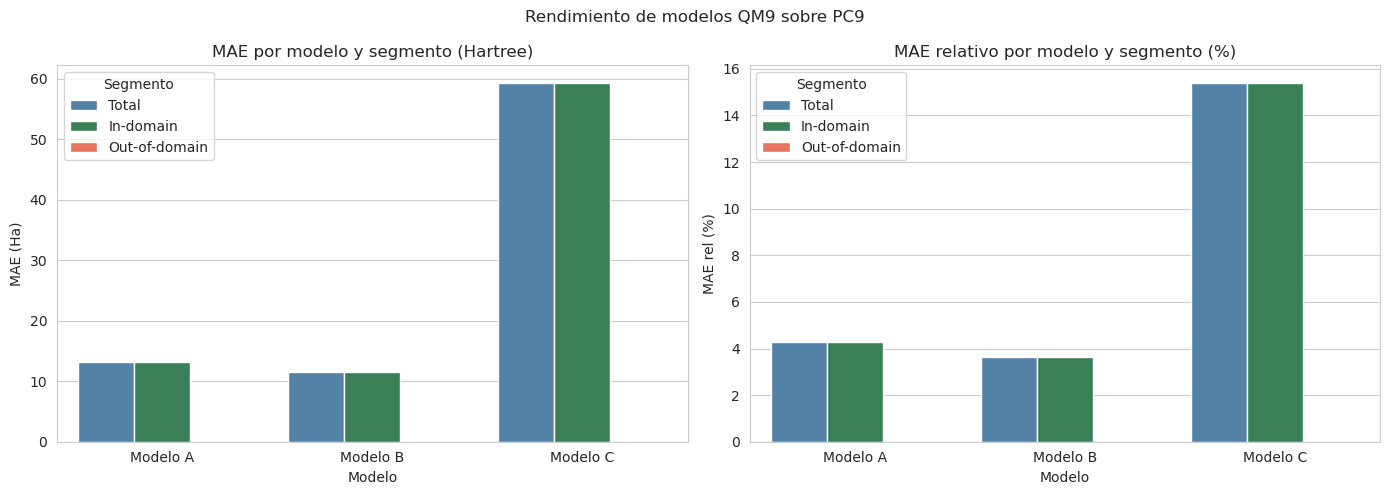

In [12]:
metrics_plot = metrics.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE absoluto
sns.barplot(
    data=metrics_plot, x="Modelo", y="MAE (Ha)",
    hue="Segmento", ax=axes[0],
    palette=["steelblue", "seagreen", "tomato"]
)
axes[0].set_title("MAE por modelo y segmento (Hartree)")
axes[0].set_ylabel("MAE (Ha)")

# MAE relativo
sns.barplot(
    data=metrics_plot, x="Modelo", y="MAE rel (%)",
    hue="Segmento", ax=axes[1],
    palette=["steelblue", "seagreen", "tomato"]
)
axes[1].set_title("MAE relativo por modelo y segmento (%)")
axes[1].set_ylabel("MAE rel (%)")

plt.suptitle("Rendimiento de modelos QM9 sobre PC9")
plt.tight_layout()
plt.show()

### 6.2 Pred vs True — scatter por modelo

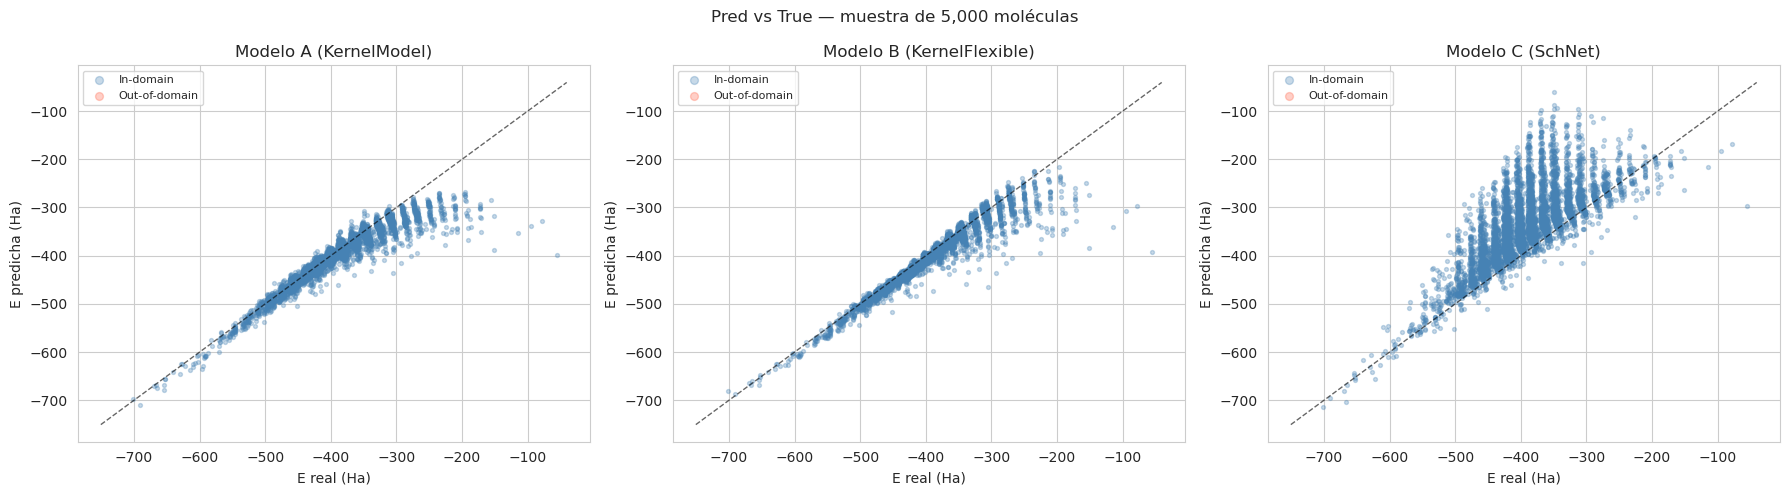

In [13]:
sample = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m, title in zip(axes, ["A", "B", "C"],
                         ["Modelo A (KernelModel)",
                          "Modelo B (KernelFlexible)",
                          "Modelo C (SchNet)"]):
    in_s  = sample[~sample["has_heavy"]]
    out_s = sample[ sample["has_heavy"]]

    ax.scatter(in_s["energy"],  in_s[f"pred_{m}"],
               alpha=0.3, s=8, color="steelblue", label="In-domain")
    ax.scatter(out_s["energy"], out_s[f"pred_{m}"],
               alpha=0.3, s=8, color="tomato",    label="Out-of-domain")

    # línea ideal
    lims = [df["energy"].min(), df["energy"].max()]
    ax.plot(lims, lims, "k--", linewidth=1, alpha=0.6)

    ax.set_xlabel("E real (Ha)")
    ax.set_ylabel("E predicha (Ha)")
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle("Pred vs True — muestra de 5,000 moléculas")
plt.tight_layout()
plt.show()

### 6.3 Distribución de errores absolutos

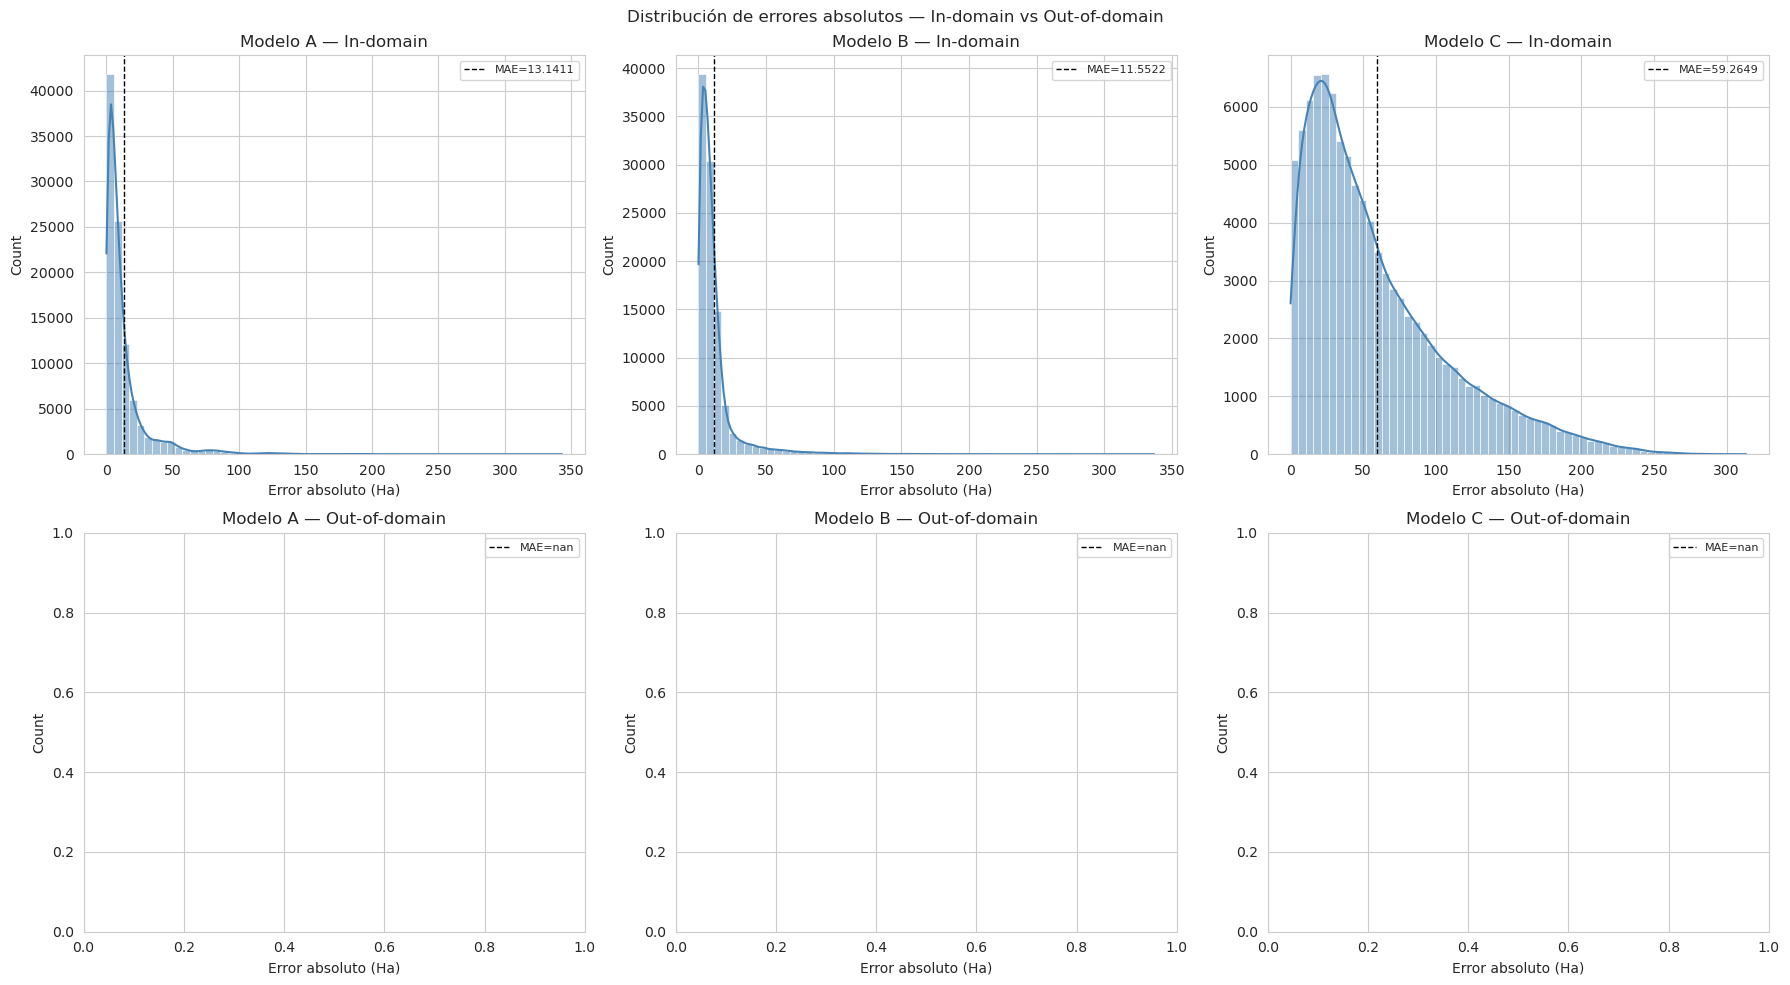

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

segments = [
    (df_in,  "In-domain",     "steelblue"),
    (df_out, "Out-of-domain", "tomato"),
]

for row, (subset, label, color) in enumerate(segments):
    for col, m in enumerate(["A", "B", "C"]):
        ax = axes[row][col]
        sns.histplot(subset[f"ae_{m}"], bins=60, kde=True, ax=ax, color=color)
        ax.set_title(f"Modelo {m} — {label}")
        ax.set_xlabel("Error absoluto (Ha)")
        ax.set_ylabel("Count")
        mae = subset[f"ae_{m}"].mean()
        ax.axvline(mae, color="black", linestyle="--", linewidth=1,
                   label=f"MAE={mae:.4f}")
        ax.legend(fontsize=8)

plt.suptitle("Distribución de errores absolutos — In-domain vs Out-of-domain")
plt.tight_layout()
plt.show()

### 6.4 Error absoluto vs tamaño molecular

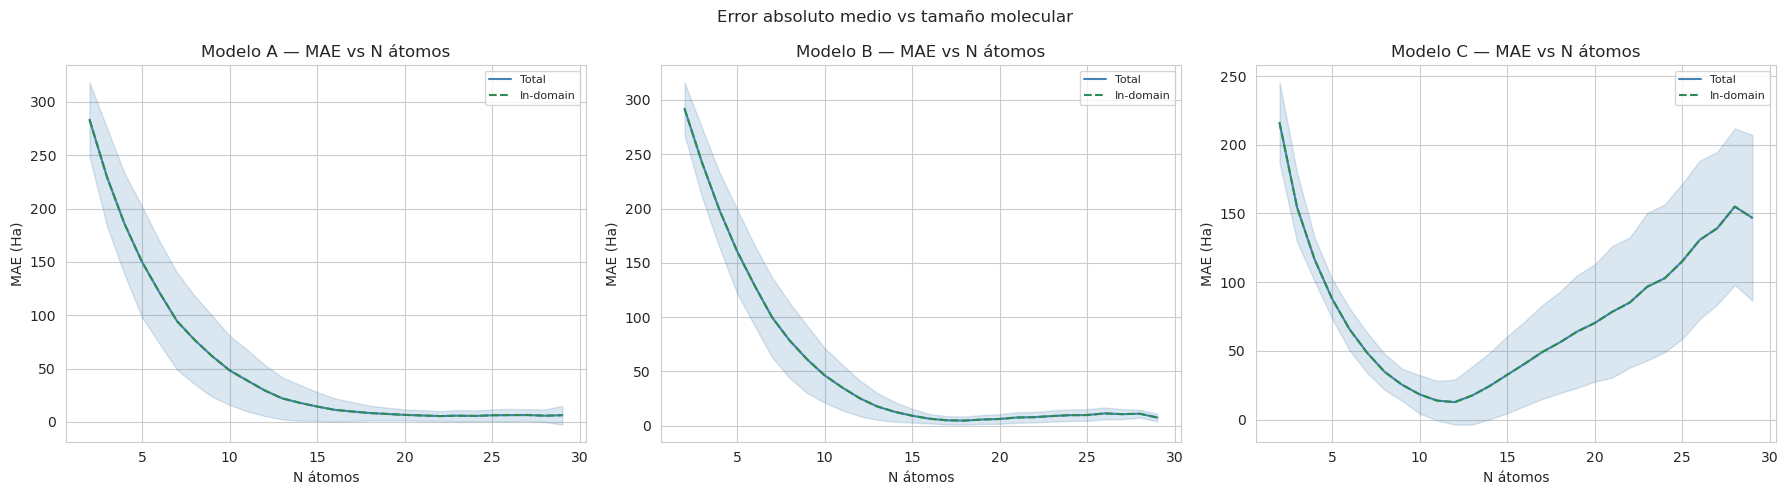

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m, title in zip(axes, ["A", "B", "C"],
                         ["Modelo A", "Modelo B", "Modelo C"]):
    sns.lineplot(
        data=df, x="n_atoms", y=f"ae_{m}",
        estimator="mean", errorbar="sd",
        ax=ax, color="steelblue", label="Total"
    )
    sns.lineplot(
        data=df_in, x="n_atoms", y=f"ae_{m}",
        estimator="mean", errorbar=None,
        ax=ax, color="seagreen", linestyle="--", label="In-domain"
    )
    ax.set_title(f"{title} — MAE vs N átomos")
    ax.set_xlabel("N átomos")
    ax.set_ylabel("MAE (Ha)")
    ax.legend(fontsize=8)

plt.suptitle("Error absoluto medio vs tamaño molecular")
plt.tight_layout()
plt.show()

### 6.5 Distribución de errores relativos

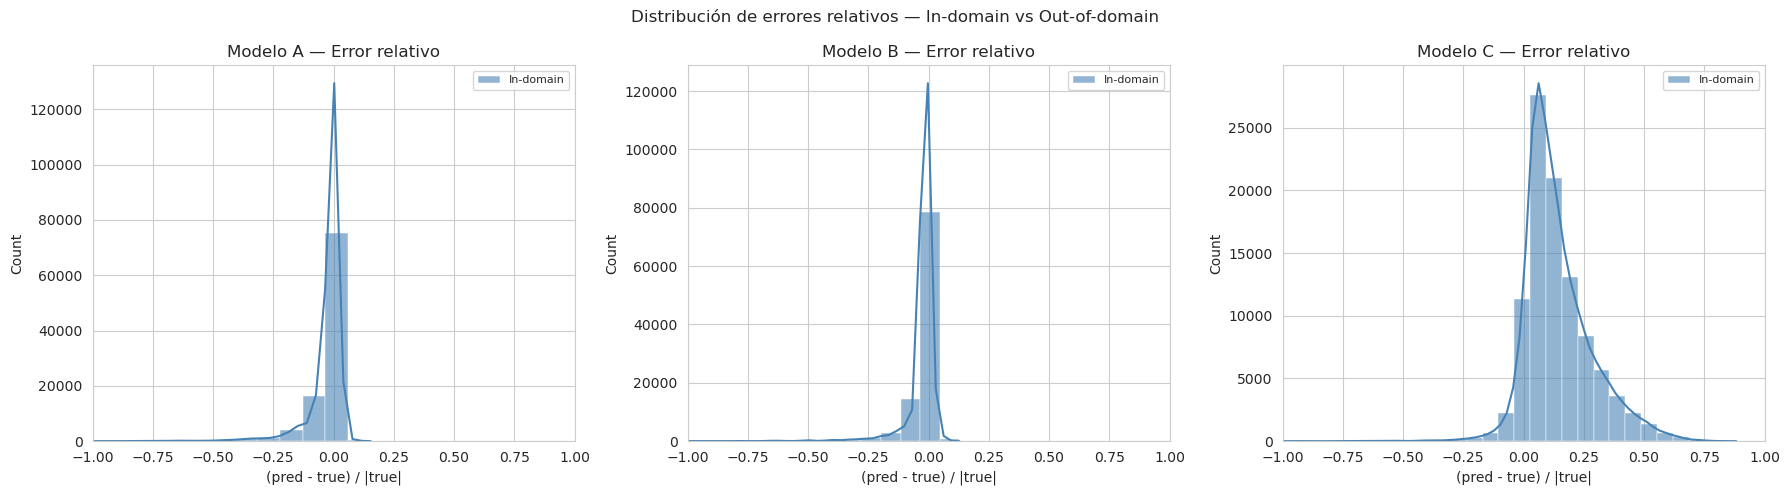

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m, title in zip(axes, ["A", "B", "C"],
                         ["Modelo A", "Modelo B", "Modelo C"]):
    sns.histplot(df_in[f"re_{m}"],  bins=80, kde=True, ax=ax,
                 color="steelblue", label="In-domain",     alpha=0.6)
    sns.histplot(df_out[f"re_{m}"], bins=80, kde=True, ax=ax,
                 color="tomato",    label="Out-of-domain", alpha=0.5)
    ax.set_title(f"{title} — Error relativo")
    ax.set_xlabel("(pred - true) / |true|")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.set_xlim(-1, 1)   # recortar outliers extremos para legibilidad

plt.suptitle("Distribución de errores relativos — In-domain vs Out-of-domain")
plt.tight_layout()
plt.show()

## 7. Resumen final

In [17]:
print("=" * 65)
print(f"{'RESUMEN DE EVALUACIÓN — QM9 → PC9':^65}")
print("=" * 65)
print(f"Total PC9:         {len(df):,}")
print(f"In-domain  (HCNOF): {len(df_in):,}  ({100*len(df_in)/len(df):.1f}%)")
print(f"Out-of-domain:      {len(df_out):,}  ({100*len(df_out)/len(df):.1f}%)")
print()

for seg, subset in [("Total", df), ("In-domain", df_in), ("Out-of-domain", df_out)]:
    print(f"--- {seg} ---")
    for m in ["A", "B", "C"]:
        mae  = subset[f"ae_{m}"].mean()
        rmse = np.sqrt((subset[f"ae_{m}"]**2).mean())
        mre  = (subset[f"re_{m}"].abs() * 100).mean()
        print(f"  Modelo {m}: MAE={mae:.4f} Ha | RMSE={rmse:.4f} Ha | MAE_rel={mre:.2f}%")
    print()

                RESUMEN DE EVALUACIÓN — QM9 → PC9                
Total PC9:         99,234
In-domain  (HCNOF): 99,234  (100.0%)
Out-of-domain:      0  (0.0%)

--- Total ---
  Modelo A: MAE=13.1411 Ha | RMSE=23.6789 Ha | MAE_rel=4.27%
  Modelo B: MAE=11.5522 Ha | RMSE=20.8541 Ha | MAE_rel=3.64%
  Modelo C: MAE=59.2649 Ha | RMSE=77.0962 Ha | MAE_rel=15.38%

--- In-domain ---
  Modelo A: MAE=13.1411 Ha | RMSE=23.6789 Ha | MAE_rel=4.27%
  Modelo B: MAE=11.5522 Ha | RMSE=20.8541 Ha | MAE_rel=3.64%
  Modelo C: MAE=59.2649 Ha | RMSE=77.0962 Ha | MAE_rel=15.38%

--- Out-of-domain ---
  Modelo A: MAE=nan Ha | RMSE=nan Ha | MAE_rel=nan%
  Modelo B: MAE=nan Ha | RMSE=nan Ha | MAE_rel=nan%
  Modelo C: MAE=nan Ha | RMSE=nan Ha | MAE_rel=nan%

